In [ ]:
# !pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
zoo = fetch_ucirepo(id=111)

X = zoo.data.features
y = zoo.data.targets.squeeze()

class_map = {
    1: "Mammal",
    2: "Bird",
    3: "Reptile",
    4: "Fish",
    5: "Amphibian",
    6: "Bug",
    7: "Invertebrate"
}

y = y.map(class_map)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.value_counts())

Feature shape: (101, 16)
Target shape: (101,)


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


type
Mammal          41
Bird            20
Fish            13
Invertebrate    10
Bug              8
Reptile          5
Amphibian        4
Name: count, dtype: int64

In [4]:
print("Missing values:")
display(X.isna().sum())

print("Target distribution:")
display(y.value_counts())

print("Feature columns:")
print(X.columns.tolist())

Missing values:


hair        0
feathers    0
eggs        0
milk        0
airborne    0
aquatic     0
predator    0
toothed     0
backbone    0
breathes    0
venomous    0
fins        0
legs        0
tail        0
domestic    0
catsize     0
dtype: int64

Target distribution:


type
Mammal          41
Bird            20
Fish            13
Invertebrate    10
Bug              8
Reptile          5
Amphibian        4
Name: count, dtype: int64

Feature columns:
['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']


In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_full
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (69, 16)
Validation size: (16, 16)
Test size: (16, 16)


In [6]:
numeric_features = X.columns.tolist()

scaled_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

tree_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features)
])

In [7]:
models = {
    "Regularized Logistic Regression": Pipeline([
        ("prep", scaled_preprocess),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            C=0.1
        ))
    ]),

    "Regularized Linear SVM": Pipeline([
        ("prep", scaled_preprocess),
        ("model", LinearSVC(
            C=0.1,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("prep", scaled_preprocess),
        ("model", KNeighborsClassifier(
            n_neighbors=3
        ))
    ]),

    "Shallow Decision Tree": Pipeline([
        ("prep", tree_preprocess),
        ("model", DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Bagging: Shallow Trees": Pipeline([
        ("prep", tree_preprocess),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=2,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42
            ),
            n_estimators=30,
            random_state=42
        ))
    ]),

    "Random Forest: Shallow Trees": Pipeline([
        ("prep", tree_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=50,
            max_depth=3,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "AdaBoost: Decision Stumps": Pipeline([
        ("prep", tree_preprocess),
        ("model", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=1,
                random_state=42
            ),
            n_estimators=30,
            learning_rate=0.5,
            random_state=42
        ))
    ])
}

In [9]:
cv_results = []

for model_name, model_pipeline in models.items():
    
    scores = cross_validate(
        model_pipeline,
        X_train_full,
        y_train_full,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro"
        }
    )
    
    cv_results.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "precision_macro": scores["test_precision_macro"].mean(),
        "recall_macro": scores["test_recall_macro"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values("f1_macro", ascending=False)

display(cv_results_df.round(3))

c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

,model,accuracy,f1_macro,precision_macro,recall_macro
0,Regularized Logistic Regression,0.976,0.953,0.976,0.946
4,Bagging: Shallow Trees,0.976,0.945,0.986,0.929
1,Regularized Linear SVM,0.965,0.914,0.952,0.911
5,Random Forest: Shallow Trees,0.965,0.914,0.952,0.911
2,KNN,0.953,0.876,0.908,0.893
6,AdaBoost: Decision Stumps,0.894,0.719,0.684,0.786
3,Shallow Decision Tree,0.610,0.527,0.527,0.655


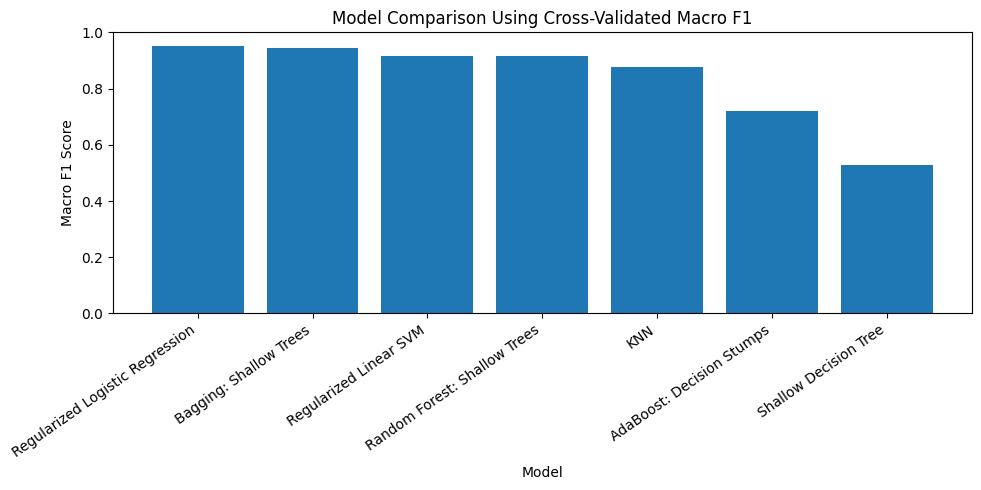

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    cv_results_df["model"],
    cv_results_df["f1_macro"]
)

plt.title("Model Comparison Using Cross-Validated Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [11]:
param_grids = {
    "Regularized Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10]
    },

    "Regularized Linear SVM": {
        "model__C": [0.01, 0.1, 1, 10]
    },

    "Shallow Decision Tree": {
        "model__max_depth": [1, 2, 3, 4],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Bagging: Shallow Trees": {
        "model__n_estimators": [10, 30, 50],
        "model__estimator__max_depth": [1, 2, 3],
        "model__estimator__min_samples_leaf": [1, 2]
    },

    "Random Forest: Shallow Trees": {
        "model__n_estimators": [30, 50, 100],
        "model__max_depth": [2, 3, 4],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "AdaBoost: Decision Stumps": {
        "model__n_estimators": [10, 30, 50],
        "model__learning_rate": [0.1, 0.5, 1.0]
    }
}

In [12]:
tuning_results = []
best_models = {}

for model_name, param_grid in param_grids.items():
    
    print(f"Tuning: {model_name}")
    
    grid_search = GridSearchCV(
        estimator=models[model_name],
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_models[model_name] = grid_search.best_estimator_
    
    val_pred = grid_search.predict(X_val)
    
    tuning_results.append({
        "model": model_name,
        "best_cv_f1_macro": grid_search.best_score_,
        "validation_accuracy": accuracy_score(y_val, val_pred),
        "validation_f1_macro": f1_score(y_val, val_pred, average="macro"),
        "validation_precision_macro": precision_score(y_val, val_pred, average="macro", zero_division=0),
        "validation_recall_macro": recall_score(y_val, val_pred, average="macro", zero_division=0),
        "best_params": grid_search.best_params_
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values("validation_f1_macro", ascending=False)

display(tuning_results_df)

Tuning: Regularized Logistic Regression
Tuning: Regularized Linear SVM
Tuning: Shallow Decision Tree
Tuning: Bagging: Shallow Trees
Tuning: Random Forest: Shallow Trees
Tuning: AdaBoost: Decision Stumps


,model,best_cv_f1_macro,validation_accuracy,validation_f1_macro,validation_precision_macro,validation_recall_macro,best_params
0,Regularized Logistic Regression,0.780241,1.0000,1.000000,1.000000,1.000000,{'model__C': 0.1}
1,Regularized Linear SVM,0.787415,1.0000,1.000000,1.000000,1.000000,{'model__C': 0.1}
3,Bagging: Shallow Trees,0.799969,1.0000,1.000000,1.000000,1.000000,"{'model__estimator__max_depth': 3, 'model__est..."
5,AdaBoost: Decision Stumps,0.735419,1.0000,1.000000,1.000000,1.000000,"{'model__learning_rate': 1.0, 'model__n_estima..."
4,Random Forest: Shallow Trees,0.871769,0.9375,0.809524,0.785714,0.857143,"{'model__max_depth': 3, 'model__min_samples_le..."
2,Shallow Decision Tree,0.676594,0.8125,0.595238,0.547619,0.714286,"{'model__max_depth': 4, 'model__min_samples_le..."


In [13]:
best_model_name = tuning_results_df.iloc[0]["model"]
best_model = best_models[best_model_name]

print("Best selected model:")
print(best_model_name)

print("\nBest parameters:")
print(tuning_results_df.iloc[0]["best_params"])

Best selected model:
Regularized Logistic Regression

Best parameters:
{'model__C': 0.1}


In [14]:
val_pred = best_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation Macro F1:", f1_score(y_val, val_pred, average="macro"))

print("\nValidation Classification Report:")
print(classification_report(y_val, val_pred, zero_division=0))

Validation Accuracy: 1.0
Validation Macro F1: 1.0

Validation Classification Report:
              precision    recall  f1-score   support

   Amphibian       1.00      1.00      1.00         1
        Bird       1.00      1.00      1.00         3
         Bug       1.00      1.00      1.00         1
        Fish       1.00      1.00      1.00         2
Invertebrate       1.00      1.00      1.00         1
      Mammal       1.00      1.00      1.00         7
     Reptile       1.00      1.00      1.00         1

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



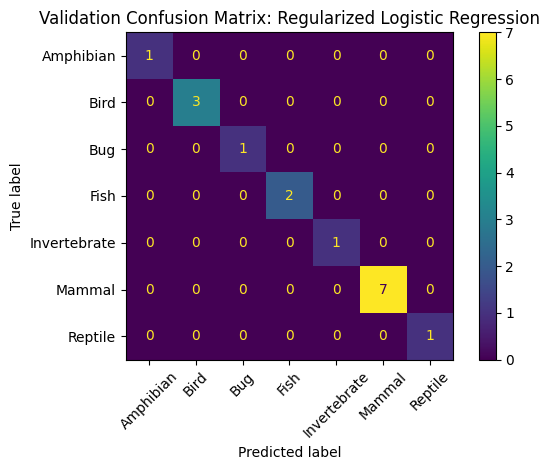

In [15]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_val,
    y_val,
    xticks_rotation=45
)

plt.title(f"Validation Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

In [16]:
final_model = best_model

final_model.fit(X_train_full, y_train_full)

test_pred = final_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, test_pred))
print("Final Test Macro F1:", f1_score(y_test, test_pred, average="macro"))
print("Final Test Precision Macro:", precision_score(y_test, test_pred, average="macro", zero_division=0))
print("Final Test Recall Macro:", recall_score(y_test, test_pred, average="macro", zero_division=0))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, test_pred, zero_division=0))

Final Test Accuracy: 0.9375
Final Test Macro F1: 0.8367346938775511
Final Test Precision Macro: 0.8214285714285714
Final Test Recall Macro: 0.8571428571428571

Final Test Classification Report:
              precision    recall  f1-score   support

   Amphibian       1.00      1.00      1.00         1
        Bird       0.75      1.00      0.86         3
         Bug       1.00      1.00      1.00         1
        Fish       1.00      1.00      1.00         2
Invertebrate       1.00      1.00      1.00         2
      Mammal       1.00      1.00      1.00         6
     Reptile       0.00      0.00      0.00         1

    accuracy                           0.94        16
   macro avg       0.82      0.86      0.84        16
weighted avg       0.89      0.94      0.91        16



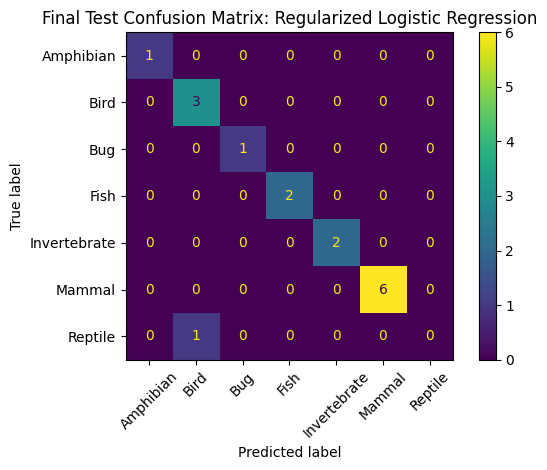

In [17]:
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    xticks_rotation=45
)

plt.title(f"Final Test Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()